In [1]:
from pynq import Overlay, allocate
import numpy as np
import time

overlay = Overlay('layer1_stream.bit')
dma = overlay.axi_dma
dma_send = overlay.axi_dma.sendchannel
dma_recv = overlay.axi_dma.recvchannel
hls_ip = overlay.layer1_stream_0

print(overlay.ip_dict.keys())

dict_keys(['layer1_stream_0', 'axi_dma', 'zynq_ultra_ps_e_0'])


In [2]:
print(hls_ip.register_map)

RegisterMap {
  CTRL = Register(AP_START=0, AP_DONE=0, AP_IDLE=1, AP_READY=0, RESERVED_1=0, AUTO_RESTART=0, RESERVED_2=0, INTERRUPT=0, RESERVED_3=0),
  GIER = Register(Enable=0, RESERVED=0),
  IP_IER = Register(CHAN0_INT_EN=0, CHAN1_INT_EN=0, RESERVED_0=0),
  IP_ISR = Register(CHAN0_INT_ST=0, CHAN1_INT_ST=0, RESERVED_0=0)
}


In [3]:
INPUT_SIZE  = 784
OUTPUT_SIZE = 128
SCALE       = 16

print(f'Input buffer: {INPUT_SIZE} values = {INPUT_SIZE * 4} bytes')
print(f'Output buffer: {OUTPUT_SIZE} values = {OUTPUT_SIZE * 4} bytes')

Input buffer: 784 values = 3136 bytes
Output buffer: 128 values = 512 bytes


In [4]:
# W1 and b1 are baked into the bitstream via weights.h -- no need to load them here
W2 = np.load('w2.npy')  # (128, 10) float32
b2 = np.load('b2.npy')  # (10,) float32

print('W2:', W2.shape)
print('b2:', b2.shape)

W2: (128, 10)
b2: (10,)


In [5]:
def load_idx_images(path):
    with open(path, 'rb') as f:
        f.read(4)
        n    = int.from_bytes(f.read(4), 'big')
        rows = int.from_bytes(f.read(4), 'big')
        cols = int.from_bytes(f.read(4), 'big')
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows, cols)

def load_idx_labels(path):
    with open(path, 'rb') as f:
        f.read(4)
        n    = int.from_bytes(f.read(4), 'big')
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

x_test = load_idx_images('t10k-images.idx3-ubyte')
y_test = load_idx_labels('t10k-labels.idx1-ubyte')

x_test_float = x_test.reshape(-1, 784).astype(np.float32) / 255.0
x_test_int   = (x_test_float * SCALE).astype(np.int32)

print(f'Test images: {x_test.shape}  |  Test labels: {y_test.shape}')

Test images: (10000, 28, 28)  |  Test labels: (10000,)


In [6]:
input_buf  = allocate(shape=(INPUT_SIZE,),  dtype=np.uint32)
output_buf = allocate(shape=(OUTPUT_SIZE,), dtype=np.uint32)

print(f'Buffers allocated: {INPUT_SIZE * 4} bytes in, {OUTPUT_SIZE * 4} bytes out')
print('W1 and b1 are baked into the bitstream -- no buffer loading needed')

Buffers allocated: 3136 bytes in, 512 bytes out
W1 and b1 are baked into the bitstream -- no buffer loading needed


In [7]:
# Write 0x81 to set AP_START (bit 0) and AUTO_RESTART (bit 7)
# AUTO_RESTART means the kernel runs without needing to be restarted
CONTROL_REGISTER = 0x0
hls_ip.write(CONTROL_REGISTER, 0x81)

print(hls_ip.register_map)

RegisterMap {
  CTRL = Register(AP_START=1, AP_DONE=0, AP_IDLE=0, AP_READY=0, RESERVED_1=0, AUTO_RESTART=1, RESERVED_2=0, INTERRUPT=0, RESERVED_3=0),
  GIER = Register(Enable=0, RESERVED=0),
  IP_IER = Register(CHAN0_INT_EN=0, CHAN1_INT_EN=0, RESERVED_0=0),
  IP_ISR = Register(CHAN0_INT_ST=0, CHAN1_INT_ST=0, RESERVED_0=0)
}


In [8]:
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

def layer1_stream_hw(image_int32):
    input_buf[:] = image_int32.view(np.uint32)

    dma_send.transfer(input_buf)
    dma_recv.transfer(output_buf)
    dma_send.wait()
    dma_recv.wait()

    return np.frombuffer(output_buf, dtype=np.int32).copy()

def forward_pass_hw(image_int32):
    a1_int   = layer1_stream_hw(image_int32)
    a1_float = a1_int.astype(np.float32) / (SCALE * SCALE)
    return softmax(a1_float @ W2 + b2)

print('Functions defined')

Functions defined


In [9]:
N = 100
img_int = x_test_int[0]

t0 = time.perf_counter()
for _ in range(N):
    layer1_stream_hw(img_int)
t1 = time.perf_counter()

hw_ms = (t1 - t0) * 1000 / N
print(f'HW Layer 1 only (avg over {N} runs): {hw_ms:.4f} ms per image')
print(f'SW baseline was 0.35 ms per image')

HW Layer 1 only (avg over 100 runs): 0.5811 ms per image
SW baseline was 0.35 ms per image


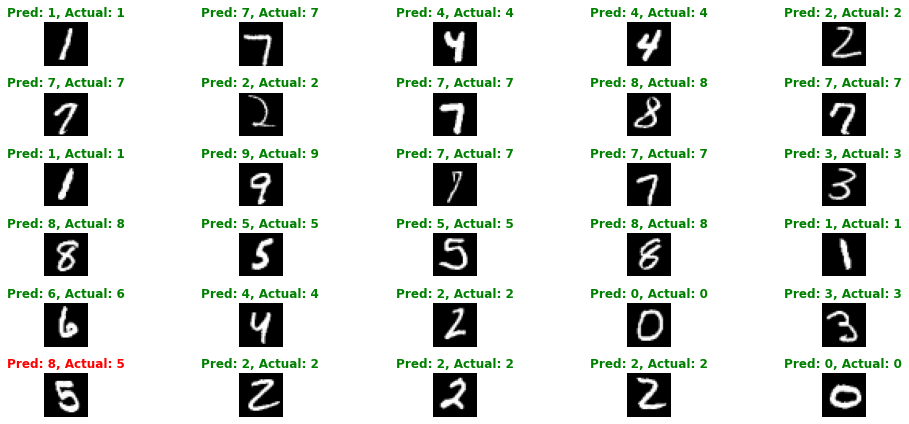


Prediction Summary:
Correctly predicted: 29 / 30

Timing (HW Layer 1 + SW Layer 2):
  Total (30 images): 23.6946 ms
  Per image: 0.7898 ms


In [10]:
import matplotlib.pyplot as plt

num_samples = 30
indices = np.random.choice(len(x_test_int), num_samples, replace=False)

t0 = time.perf_counter()
predictions = np.array([forward_pass_hw(x_test_int[i]) for i in indices])
t1 = time.perf_counter()

predicted_labels = np.argmax(predictions, axis=1)
total_ms     = (t1 - t0) * 1000
per_image_ms = total_ms / num_samples

fig, axes = plt.subplots(6, 5, figsize=(15, 6))
axes = axes.flatten()
for idx, ax in enumerate(axes):
    image = x_test[indices[idx]].reshape(28, 28)
    ax.imshow(image, cmap='gray')
    predicted = predicted_labels[idx]
    actual    = y_test[indices[idx]]
    color     = 'green' if predicted == actual else 'red'
    ax.set_title(f'Pred: {predicted}, Actual: {actual}', color=color, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f'\nPrediction Summary:')
print(f'Correctly predicted: {np.sum(predicted_labels == y_test[indices])} / {num_samples}')
print(f'\nTiming (HW Layer 1 + SW Layer 2):')
print(f'  Total ({num_samples} images): {total_ms:.4f} ms')
print(f'  Per image: {per_image_ms:.4f} ms')

In [11]:
N_total = len(x_test_int)

t0 = time.perf_counter()
all_predictions = np.array([
    np.argmax(forward_pass_hw(x_test_int[i]))
    for i in range(N_total)
])
t1 = time.perf_counter()

total_ms     = (t1 - t0) * 1000
per_image_ms = total_ms / N_total
accuracy     = np.sum(all_predictions == y_test) / N_total

print(f'Full test set results ({N_total} images):')
print(f'  Accuracy:      {accuracy:.2%}')
print(f'  Total time:    {total_ms:.2f} ms')
print(f'  Per image:     {per_image_ms:.4f} ms')

Full test set results (10000 images):
  Accuracy:      97.80%
  Total time:    7840.28 ms
  Per image:     0.7840 ms
